In [3]:
from google.colab import files
uploaded = files.upload()

Saving Annual Reports.zip to Annual Reports.zip


In [4]:
import zipfile
import os

zip_path = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("data")

print(os.listdir("data"))

['Annual Reports', '__MACOSX']


In [5]:
for folder in os.listdir("data"):
    print(folder, "→", os.listdir(os.path.join("data", folder)))

Annual Reports → ['AALTO', '.DS_Store', 'KTU', 'LSMU', 'Cambridge', 'Oslo', 'ULV', 'TCD', 'RWTH', 'HHFinland', 'Harvard', 'Helsinki', 'TLU', 'Tartu', 'Oxford', 'RTU', 'ETHzurich', 'VDU']
__MACOSX → ['Annual Reports']


In [6]:
!pip install pymupdf pdfplumber pytesseract pdf2image scikit-learn pandas matplotlib seaborn
!apt-get update
!apt-get install -y poppler-utils tesseract-ocr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 85.9 MB/s eta 0:00:00
Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://cloud.r-project.org/bi

In [7]:
import os
import fitz
import pytesseract
from pdf2image import convert_from_path
import re
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

BASE_PATH = "data/Annual Reports"

In [8]:
def extract_text_from_pdf(file_path):
    text = ""
    try:
        doc = fitz.open(file_path)
        for page in doc:
            text += page.get_text()
    except:
        pass

    if len(text) < 1000:
        try:
            images = convert_from_path(file_path)
            for img in images:
                text += pytesseract.image_to_string(img)
        except:
            pass

    return text

In [9]:
university_texts = {}

for university in os.listdir(BASE_PATH):

    if university.startswith(".") or university.startswith("__"):
        continue

    uni_path = os.path.join(BASE_PATH, university)

    if os.path.isdir(uni_path):
        combined_text = ""

        for file in os.listdir(uni_path):

            if file.startswith(".") or file.startswith("__"):
                continue

            if file.endswith(".pdf"):
                file_path = os.path.join(uni_path, file)
                print(f"Processing {university} → {file}")
                text = extract_text_from_pdf(file_path)
                combined_text += text + " "

        university_texts[university] = combined_text

print("\nLoaded universities:", list(university_texts.keys()))

Processing AALTO → AALTO_2025_EN.pdf
Processing AALTO → AALTO_2025_EN_Review.pdf
Processing KTU → KTU_2025_EN_Activity.pdf
Processing KTU → KTU_2022_EN.pdf
Processing KTU → KTU_2021-25_EN_Strategy.pdf
Processing KTU → KTU_2025_LT.pdf
Processing KTU → KTU_2024_EN.pdf
Processing KTU → KTU_2025_LT_Finance.pdf
Processing KTU → KTU_2026-28_LT_StrategicPlan.pdf
Processing LSMU → LSMU_2024_LT.pdf
Processing Cambridge → Cambridge_2025_EN.pdf
Processing Oslo → Oslo_2024_EN.pdf
Processing ULV → ULV_2021-27_MIX_Strategy.pdf
Processing ULV → ULV_2030_EN_SPlan.pdf
Processing ULV → ULV_2030_EN_Plan.pdf
Processing ULV → ULV_2023_MIX.pdf
Processing TCD → TCD_2023_EN_Electives.pdf
Processing TCD → TCD_2021_EN_WPG.pdf
Processing TCD → TCD_2025-30_EN_Strategy.pdf
Processing TCD → TCD_2024_EN_Finance.pdf
Processing TCD → TCD_2024_EN.pdf
Processing TCD → TCD_2023_EN_GSC.pdf
Processing RWTH → RWTH_2024_EN.pdf
Processing HHFinland → HHFinland_2024_EN.pdf
Processing Harvard → Harvard_2025_EN_Finance.pdf
Proce

In [10]:
for uni, text in university_texts.items():
    print(uni, "→ text length:", len(text))

AALTO → text length: 151773
KTU → text length: 521085
LSMU → text length: 442519
Cambridge → text length: 350551
Oslo → text length: 101237
ULV → text length: 118064
TCD → text length: 527603
RWTH → text length: 547254
HHFinland → text length: 36848
Harvard → text length: 149175
Helsinki → text length: 204509
TLU → text length: 237068
Tartu → text length: 262043
Oxford → text length: 428937
RTU → text length: 118327
ETHzurich → text length: 711322
VDU → text length: 1011522


In [11]:
analysis_data = []

kpi_terms = [
    # English
    "kpi", "performance", "indicator", "target", "benchmark",
    "metric", "measure", "objective", "outcome", "result",
    # Lithuanian
    "rodiklis", "rodikliai", "tikslas", "rezultatas",
    "veiklos rodiklis", "veiklos rezultatas", "pasiekimas"
]

positive_terms = [
    # English
    "increase", "growth", "improvement", "rise", "expansion",
    "success", "achievement", "strengthening", "progress",
    # Lithuanian
    "augimas", "padidėjimas", "gerėjimas", "stiprėjimas",
    "sėkmė", "pasiekimas", "plėtra"
]

risk_terms = [
    "risk", "rizika", "uncertainty", "neapibrėžtumas"
]

crisis_terms = [
    "crisis", "problem", "deficit", "krizė", "problema"
]

theme_dictionary = {
    "finance": [
        "finance", "financial", "budget", "revenue", "income",
        "funding", "expenditure", "cost",
        "finansai", "biudžetas", "pajamos", "išlaidos"
    ],
    "students": [
        "student", "students", "enrollment", "education",
        "studijų", "studentai", "mokymas", "studijos"
    ],
    "staff": [
        "staff", "faculty", "professor", "researcher",
        "darbuotojai", "profesoriai", "tyrėjai", "akademinis personalas"
    ],
    "research": [
        "research", "publication", "innovation", "laboratory",
        "mokslas", "tyrimai", "publikacijos", "inovacijos"
    ],
    "strategy": [
        "strategy", "strategic", "governance", "policy",
        "strategija", "valdymas", "politika"
    ],
    "risk": [
        "risk", "challenge", "uncertainty",
        "rizika", "iššūkis", "neapibrėžtumas"
    ],
    "international": [
        "international", "global", "exchange",
        "tarptautinis", "tarptautinė", "mainai"
    ],
    "society": [
        "society", "community", "public", "impact",
        "visuomenė", "bendruomenė", "poveikis"
    ]
}

for uni, text in university_texts.items():

    text_lower = text.lower()
    words = re.findall(r'\b\w+\b', text_lower)
    word_count = len(words)

    numbers = re.findall(r'\d+', text)
    numeric_count = len(numbers)

    years = re.findall(r'20\d{2}', text)
    unique_years = set(years)

    kpi_count = sum(text_lower.count(term) for term in kpi_terms)

    positive_count = sum(text_lower.count(term) for term in positive_terms)
    risk_count = sum(text_lower.count(term) for term in risk_terms)
    crisis_count = sum(text_lower.count(term) for term in crisis_terms)

    risk_density = risk_count / word_count if word_count else 0
    crisis_density = crisis_count / word_count if word_count else 0

    sentiment_balance = positive_count - crisis_count

    theme_counts = {}
    for theme, keywords in theme_dictionary.items():
        theme_counts[theme] = sum(text_lower.count(word) for word in keywords)

    analysis_data.append({
        "University": uni,
        "Word_Count": word_count,
        "Numeric_Count": numeric_count,
        "Numeric_Ratio": numeric_count / word_count if word_count else 0,
        "Unique_Years": len(unique_years),
        "KPI_Density": kpi_count / word_count if word_count else 0,
        "Positive_Terms": positive_count,
        "Risk_Density": risk_density,
        "Crisis_Density": crisis_density,
        "Sentiment_Balance": sentiment_balance,
        **theme_counts
    })

df_analysis = pd.DataFrame(analysis_data)

df_analysis.sort_values("Word_Count", ascending=False)

,University,Word_Count,Numeric_Count,Numeric_Ratio,Unique_Years,KPI_Density,Positive_Terms,Risk_Density,Crisis_Density,Sentiment_Balance,finance,students,staff,research,strategy,risk,international,society
16,VDU,136446,14238,0.104349,35,0.001935,354,0.000044,0.000213,325,190,3186,620,747,143,31,509,657
15,ETHzurich,114529,16119,0.140742,34,0.005309,442,0.002279,0.001118,314,1702,486,309,847,257,290,274,186
6,TCD,82418,17817,0.216179,39,0.002694,333,0.000922,0.000267,311,740,1396,239,252,263,118,80,165
7,RWTH,75606,1473,0.019483,29,0.001098,118,0.000344,0.000807,57,66,229,404,645,50,119,203,104
1,KTU,72186,7916,0.109661,35,0.002327,201,0.000222,0.000388,173,141,1290,182,689,71,61,316,409
13,Oxford,67489,9878,0.146365,28,0.003764,299,0.003778,0.000667,254,1140,450,198,368,208,286,137,222
2,LSMU,59813,14559,0.243409,21,0.003795,50,0.000117,0.000201,38,88,606,62,62,17,8,58,116
3,Cambridge,56280,9823,0.174538,32,0.003429,196,0.003340,0.001439,115,1063,225,108,218,85,196,90,114
12,Tartu,41142,5624,0.136697,22,0.003816,133,0.000486,0.000486,113,550,630,269,321,50,21,131,127
10,Helsinki,36835,17716,0.480956,20,0.001140,38,0.000787,0.000136,33,590,302,432,262,16,32,60,88


In [12]:
from sklearn.preprocessing import StandardScaler

features = df_analysis.drop(columns=["University"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

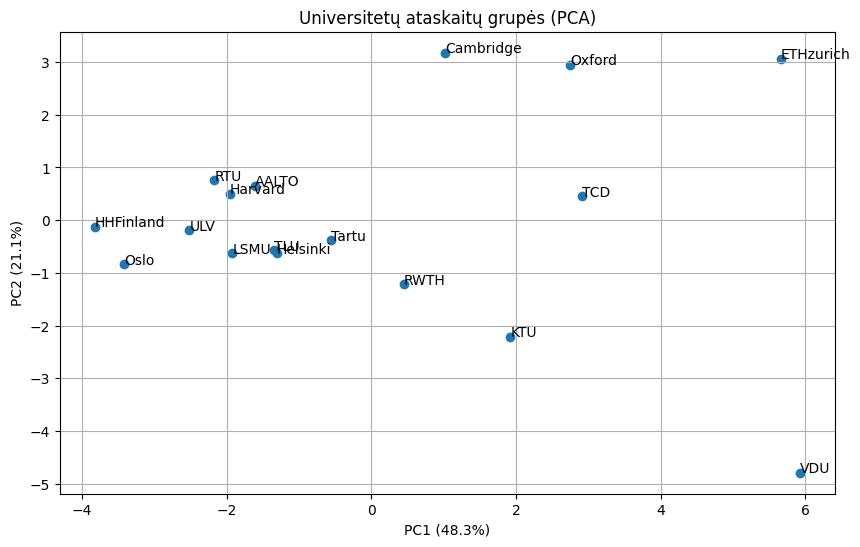

In [13]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_analysis["PC1"] = X_pca[:, 0]
df_analysis["PC2"] = X_pca[:, 1]

plt.figure(figsize=(10,6))
plt.scatter(df_analysis["PC1"], df_analysis["PC2"])

for i, uni in enumerate(df_analysis["University"]):
    plt.text(df_analysis["PC1"][i], df_analysis["PC2"][i], uni)

plt.title("Universitetų ataskaitų grupės (PCA)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.grid()
plt.show()

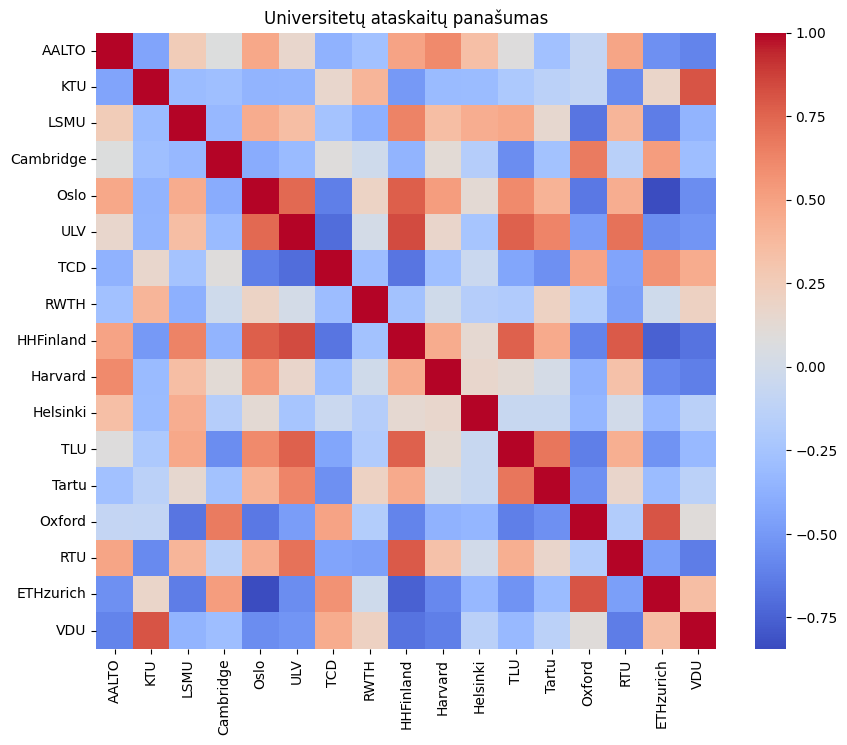

In [14]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns

similarity_matrix = cosine_similarity(X_scaled)

plt.figure(figsize=(10,8))
sns.heatmap(similarity_matrix,
            xticklabels=df_analysis["University"],
            yticklabels=df_analysis["University"],
            cmap="coolwarm")

plt.title("Universitetų ataskaitų panašumas")
plt.show()

In [15]:

df_norm = df_analysis.copy()

for col in ["Numeric_Ratio", "KPI_Density", "Unique_Years", "Sentiment_Balance"]:
    df_norm[col] = (df_norm[col] - df_norm[col].min()) / (df_norm[col].max() - df_norm[col].min())

df_analysis["Maturity_Index"] = (
    0.3 * df_norm["Numeric_Ratio"] +
    0.3 * df_norm["KPI_Density"] +
    0.2 * df_norm["Unique_Years"] +
    0.2 * df_norm["Sentiment_Balance"]
)

df_analysis.sort_values("Maturity_Index", ascending=False)

,University,Word_Count,Numeric_Count,Numeric_Ratio,Unique_Years,KPI_Density,Positive_Terms,Risk_Density,Crisis_Density,Sentiment_Balance,...,students,staff,research,strategy,risk,international,society,PC1,PC2,Maturity_Index
15,ETHzurich,114529,16119,0.140742,34,0.005309,442,0.002279,0.001118,314,...,486,309,847,257,290,274,186,5.664950,3.062781,0.735855
6,TCD,82418,17817,0.216179,39,0.002694,333,0.000922,0.000267,311,...,1396,239,252,263,118,80,165,2.917485,0.458688,0.632319
13,Oxford,67489,9878,0.146365,28,0.003764,299,0.003778,0.000667,254,...,450,198,368,208,286,137,222,2.748972,2.947473,0.546969
14,RTU,18203,3836,0.210734,19,0.005164,46,0.002033,0.000055,45,...,176,96,120,123,43,57,144,-2.174111,0.754089,0.486346
16,VDU,136446,14238,0.104349,35,0.001935,354,0.000044,0.000213,325,...,3186,620,747,143,31,509,657,5.921196,-4.792676,0.486233
3,Cambridge,56280,9823,0.174538,32,0.003429,196,0.003340,0.001439,115,...,225,108,218,85,196,90,114,1.023069,3.176863,0.478290
11,TLU,36293,5340,0.147136,18,0.004133,151,0.000055,0.000165,145,...,599,134,308,35,4,70,110,-1.348807,-0.565302,0.430415
9,Harvard,23371,4530,0.193830,39,0.002353,60,0.001326,0.000342,52,...,113,45,77,24,36,32,49,-1.959290,0.499587,0.422594
2,LSMU,59813,14559,0.243409,21,0.003795,50,0.000117,0.000201,38,...,606,62,62,17,8,58,116,-1.925551,-0.626798,0.419732
1,KTU,72186,7916,0.109661,35,0.002327,201,0.000222,0.000388,173,...,1290,182,689,71,61,316,409,1.920671,-2.208334,0.417319


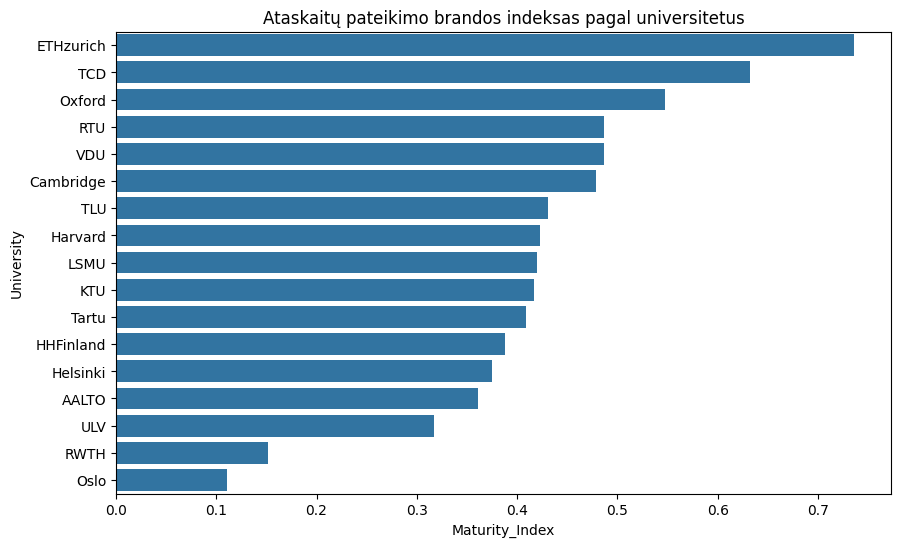

In [17]:
plt.figure(figsize=(10,6))
sns.barplot(data=df_analysis.sort_values("Maturity_Index", ascending=False),
            x="Maturity_Index", y="University")

plt.title("Ataskaitų pateikimo brandos indeksas pagal universitetus")
plt.show()

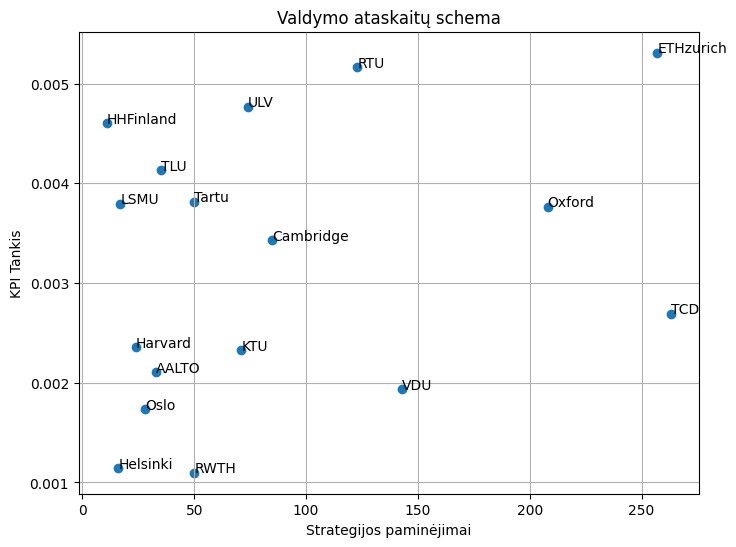

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(df_analysis["strategy"], df_analysis["KPI_Density"])

for i, uni in enumerate(df_analysis["University"]):
    plt.text(df_analysis["strategy"][i], df_analysis["KPI_Density"][i], uni)

plt.xlabel("Strategijos paminėjimai")
plt.ylabel("KPI Tankis")
plt.title("Valdymo ataskaitų schema")

plt.grid()
plt.show()

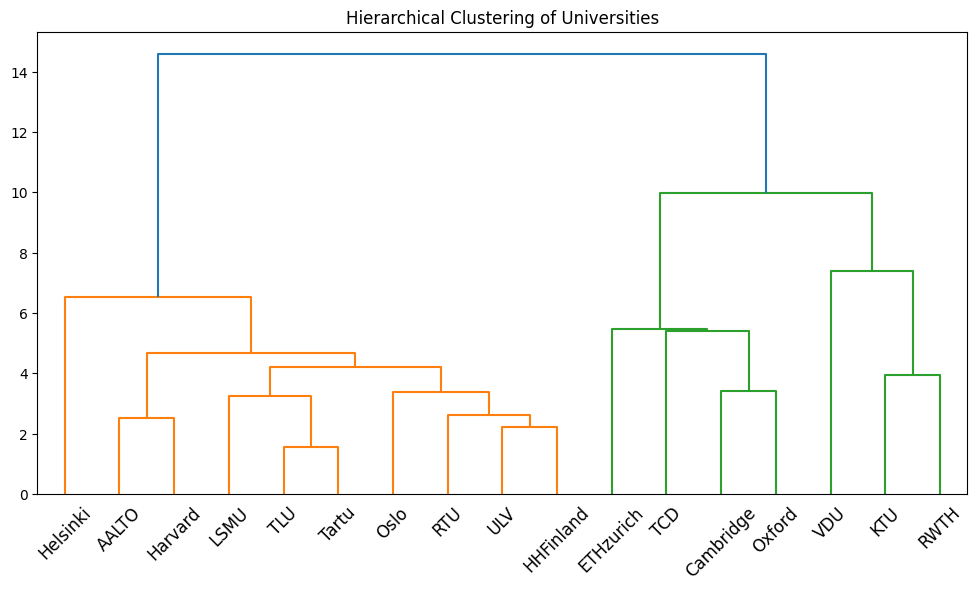

In [19]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12,6))
dendrogram(linked,
           labels=df_analysis["University"].values)

plt.title("Hierarchical Clustering of Universities")
plt.xticks(rotation=45)
plt.show()

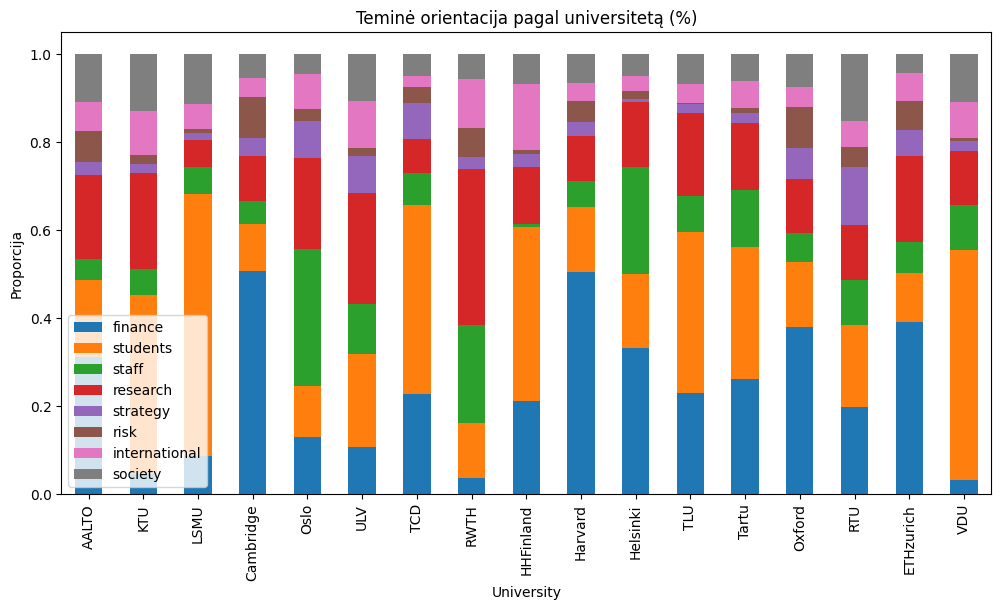

In [20]:
themes = ["finance", "students", "staff", "research", "strategy", "risk", "international", "society"]

df_topics = df_analysis.copy()

df_topics["Total_Themes"] = df_topics[themes].sum(axis=1)

for t in themes:
    df_topics[t] = df_topics[t] / df_topics["Total_Themes"]

df_topics.set_index("University")[themes].plot(kind="bar", stacked=True, figsize=(12,6))

plt.title("Teminė orientacija pagal universitetą (%)")
plt.ylabel("Proporcija")
plt.show()

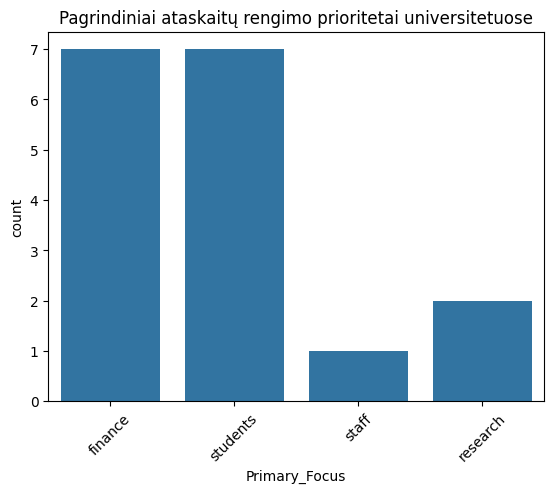

In [21]:
df_analysis["Primary_Focus"] = df_analysis[themes].idxmax(axis=1)

sns.countplot(data=df_analysis, x="Primary_Focus")

plt.title("Pagrindiniai ataskaitų rengimo prioritetai universitetuose")
plt.xticks(rotation=45)
plt.show()

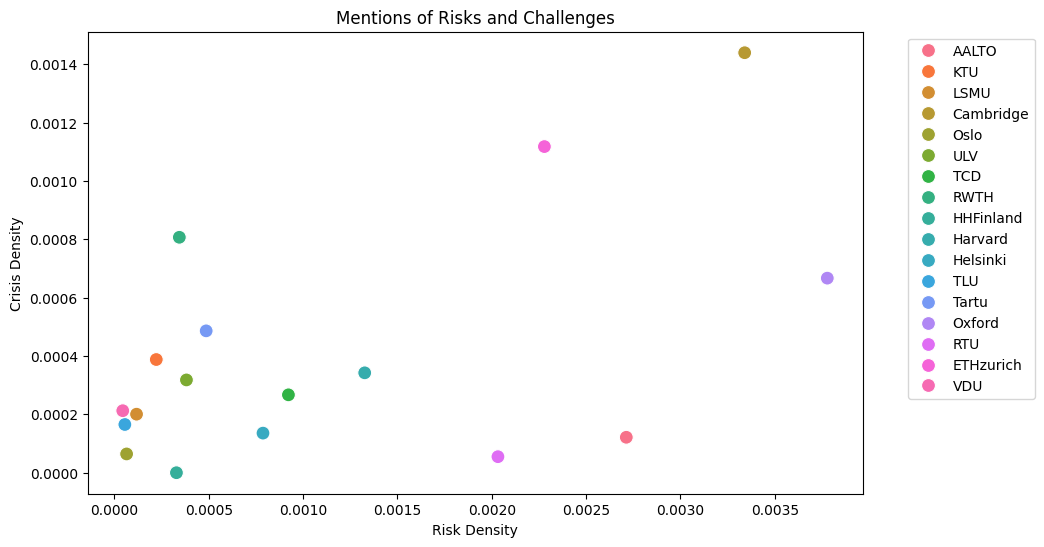

In [24]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_analysis,
    x="Risk_Density",
    y="Crisis_Density",
    hue="University",
    s=100
)

plt.title("Mentions of Risks and Challenges")
plt.xlabel("Risk Density")
plt.ylabel("Crisis Density")
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()

In [25]:
topic_columns = ["Research", "Students", "Finance", "Strategy", "Staff"]
topic_share_cols = [col + "_Share_%" for col in topic_columns]

plot_df = df_text.set_index("University")[topic_share_cols]

plot_df.plot(kind="bar", figsize=(12, 6))

plt.title("Topic Focus by University (%)")
plt.ylabel("Percentage")
plt.xlabel("University")
plt.xticks(rotation=45)
plt.legend(title="Topics", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

NameError: name 'topic_columns' is not defined

In [ ]:
from sklearn.preprocessing import MinMaxScaler

df_index = df_analysis.copy()

features = [
    "KPI_Count",
    "Negative_Terms",
    "Numeric_Ratio",
    "Unique_Years",
    "strategy",
    "research",
    "finance"
]

scaler = MinMaxScaler()
df_scaled = df_index.copy()
df_scaled[features] = scaler.fit_transform(df_index[features])

KeyError: "['KPI_Count', 'Negative_Terms'] not in index"

In [ ]:
weights = {
    "KPI_Count": 0.2,
    "Negative_Terms": 0.2,
    "Numeric_Ratio": 0.15,
    "Unique_Years": 0.15,
    "strategy": 0.1,
    "research": 0.1,
    "finance": 0.1
}

df_scaled["Reporting_Maturity_Index"] = (
    df_scaled["KPI_Count"] * weights["KPI_Count"] +
    df_scaled["Negative_Terms"] * weights["Negative_Terms"] +
    df_scaled["Numeric_Ratio"] * weights["Numeric_Ratio"] +
    df_scaled["Unique_Years"] * weights["Unique_Years"] +
    df_scaled["strategy"] * weights["strategy"] +
    df_scaled["research"] * weights["research"] +
    df_scaled["finance"] * weights["finance"]
)

df_scaled.sort_values("Reporting_Maturity_Index", ascending=False)

,University,Word_Count,Numeric_Count,Numeric_Ratio,Unique_Years,KPI_Count,Positive_Terms,Negative_Terms,Sentiment_Balance,finance,students,staff,research,strategy,risk,international,society,Reporting_Maturity_Index
15,ETHzurich,110804,16119,0.206409,0.821429,1.000000,442,1.000000,-71,1.000000,486,309,1.000000,0.976190,290,274,186,0.851795
13,Oxford,63505,9878,0.222932,0.607143,0.390706,299,0.731755,-78,0.661242,450,198,0.398996,0.781746,286,137,222,0.533202
6,TCD,78585,17817,0.339672,1.000000,0.335628,333,0.315582,167,0.420133,1396,239,0.253450,1.000000,118,80,165,0.498551
3,Cambridge,52420,9823,0.275161,0.750000,0.285714,196,0.570020,-99,0.614828,225,108,0.210790,0.293651,196,90,114,0.436848
16,VDU,132836,14238,0.143610,0.857143,0.407917,354,0.167653,263,0.088608,3186,620,0.874529,0.523810,31,509,657,0.413922
1,KTU,70960,7916,0.150779,0.857143,0.242685,201,0.185404,101,0.059072,1290,182,0.801757,0.238095,61,316,409,0.346699
10,Helsinki,28151,17716,1.000000,0.321429,0.025818,38,0.082840,-10,0.329717,302,432,0.265997,0.019841,32,60,88,0.281501
7,RWTH,75051,1473,0.000000,0.642857,0.096386,118,0.364892,-73,0.013864,229,404,0.746550,0.154762,119,203,104,0.280202
9,Harvard,21586,4530,0.312012,1.000000,0.048193,60,0.090730,8,0.204340,113,45,0.033877,0.051587,36,32,49,0.253567
12,Tartu,39276,5624,0.202667,0.392857,0.223752,133,0.122288,65,0.305606,630,269,0.340025,0.154762,21,131,127,0.238576


In [ ]:
from sklearn.cluster import KMeans

cluster_features = [
    "KPI_Count",
    "Negative_Terms",
    "Numeric_Ratio",
    "Unique_Years",
    "research"
]

X = df_scaled[cluster_features]

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df_scaled["Cluster"] = kmeans.fit_predict(X)

df_scaled[["University", "Reporting_Maturity_Index", "Cluster"]]

,University,Reporting_Maturity_Index,Cluster
0,AALTO,0.217147,1
1,KTU,0.346699,2
2,LSMU,0.195079,1
3,Cambridge,0.436848,0
4,Oslo,0.042855,1
5,ULV,0.085944,1
6,TCD,0.498551,0
7,RWTH,0.280202,2
8,HHFinland,0.062191,1
9,Harvard,0.253567,0


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df_scaled["Cluster"])

for i, uni in enumerate(df_scaled["University"]):
    plt.text(X_pca[i,0], X_pca[i,1], uni)

plt.title("University Reporting Clusters (PCA)")
plt.show()

KeyError: 'Cluster'

<Figure size 800x600 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

df_sorted = df_scaled.sort_values("Reporting_Maturity_Index", ascending=False)

plt.figure(figsize=(10,6))
plt.bar(df_sorted["University"], df_sorted["Reporting_Maturity_Index"])
plt.xticks(rotation=45)
plt.title("Reporting Maturity Index by University")
plt.ylabel("Maturity Score (0-1)")
plt.show()

KeyError: 'Reporting_Maturity_Index'

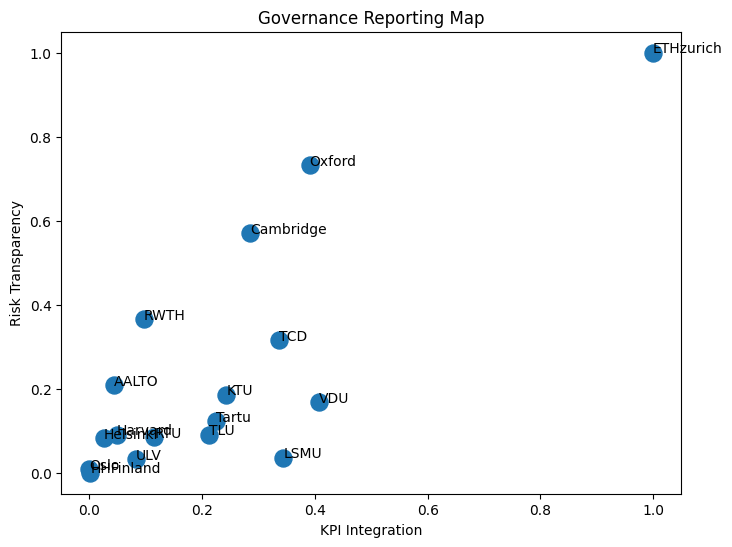

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(df_scaled["KPI_Count"],
            df_scaled["Negative_Terms"],
            s=150)

for i, row in df_scaled.iterrows():
    plt.text(row["KPI_Count"], row["Negative_Terms"], row["University"])

plt.xlabel("KPI Integration")
plt.ylabel("Risk Transparency")
plt.title("Governance Reporting Map")
plt.show()

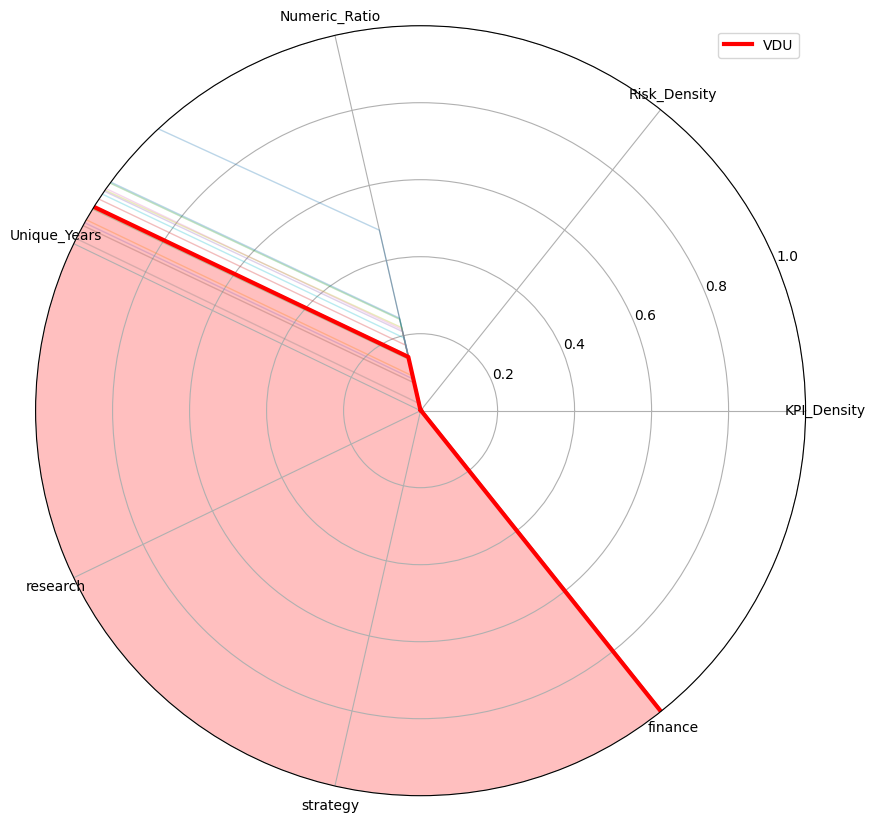

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

features = [
    "KPI_Density",
    "Risk_Density",
    "Numeric_Ratio",
    "Unique_Years",
    "research",
    "strategy",
    "finance"
]

labels = features
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(10,10))
ax = plt.subplot(111, polar=True)

for i, row in df_scaled.iterrows():

    values = row[features].tolist()
    values += values[:1]

    if row["University"] != "VDU":
        ax.plot(angles, values, linewidth=1, alpha=0.3)
    else:
        vdu_values = values

ax.plot(angles, vdu_values, linewidth=3, label="VDU", color="red")
ax.fill(angles, vdu_values, alpha=0.25, color="red")

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(0,1)

plt.legend()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

weights_base = {
    "KPI_Count": 0.25,
    "Negative_Terms": 0.25,
    "Numeric_Ratio": 0.15,
    "Unique_Years": 0.15,
    "research": 0.10,
    "strategy": 0.10
}

def calculate_index(df, weights):
    index = 0
    for k,v in weights.items():
        index += df[k] * v
    return index

results = []

for risk_weight in np.arange(0.1, 0.5, 0.05):

    weights = weights_base.copy()
    weights["Negative_Terms"] = risk_weight

    other_total = 1 - risk_weight
    base_other = sum([v for k,v in weights_base.items() if k!="Negative_Terms"])

    for k in weights:
        if k!="Negative_Terms":
            weights[k] = weights_base[k] / base_other * other_total

    df_scaled["Sensitivity_Index"] = calculate_index(df_scaled, weights)

    vdu_score = df_scaled[df_scaled["University"]=="VDU"]["Sensitivity_Index"].values[0]

    results.append((risk_weight, vdu_score))

sensitivity_df = pd.DataFrame(results, columns=["Risk_Weight","VDU_Index"])
sensitivity_df

,Risk_Weight,VDU_Index
0,0.10,0.487077
1,0.15,0.469331
2,0.20,0.451585
3,0.25,0.433839
4,0.30,0.416094
5,0.35,0.398348
6,0.40,0.380602
7,0.45,0.362856


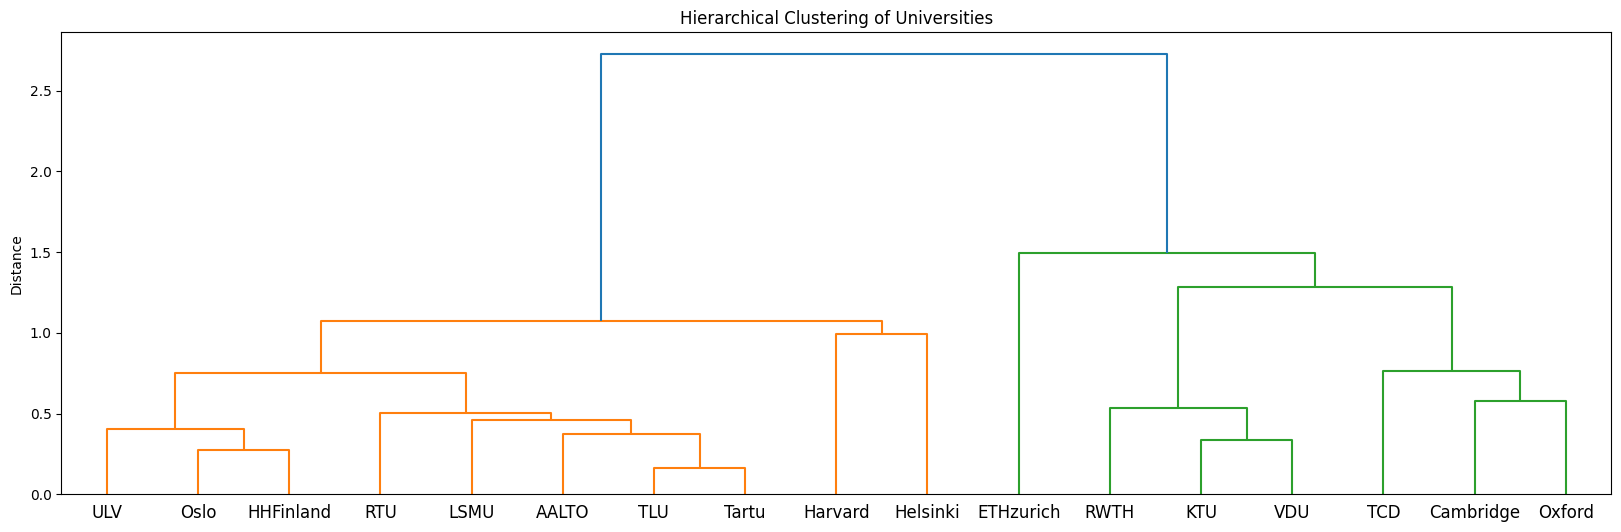

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

features_cluster = [
    "KPI_Count","Negative_Terms","Numeric_Ratio",
    "Unique_Years","research","strategy"
]

X = df_scaled[features_cluster]

linked = linkage(X, method='ward')

plt.figure(figsize=(20,6))
dendrogram(linked,
           labels=df_scaled["University"].values,
           orientation='top')
plt.title("Hierarchical Clustering of Universities")
plt.ylabel("Distance")
plt.show()

In [ ]:
scorecard = df_scaled.copy()

for col in features_cluster:
    scorecard[col+"_Rank"] = scorecard[col].rank(ascending=False)

scorecard = scorecard.sort_values("University")
scorecard[["University"] + [c for c in scorecard.columns if "Rank" in c]]

,University,KPI_Count_Rank,Negative_Terms_Rank,Numeric_Ratio_Rank,Unique_Years_Rank,research_Rank,strategy_Rank
0,AALTO,14.0,6.0,3.0,9.0,12.0,12.0
3,Cambridge,6.0,3.0,8.0,6.0,11.0,6.0
15,ETHzurich,1.0,1.0,11.0,5.0,1.0,2.0
8,HHFinland,16.0,17.0,4.0,16.0,17.0,17.0
9,Harvard,13.0,10.5,7.0,1.5,14.0,14.0
10,Helsinki,15.0,13.0,1.0,12.0,8.0,16.0
1,KTU,7.0,7.0,13.0,3.5,3.0,8.0
2,LSMU,4.0,14.0,2.0,11.0,16.0,15.0
4,Oslo,17.0,16.0,15.0,15.0,15.0,13.0
13,Oxford,3.0,2.0,9.0,8.0,5.0,3.0


In [ ]:

df_scaled["Reporting_Index"] = calculate_index(df_scaled, weights_base)

df_sim = df_scaled.copy()

vdu_index = df_sim[df_sim["University"]=="VDU"].index[0]

original = df_sim.loc[vdu_index,"Negative_Terms"]

df_sim.loc[vdu_index,"Negative_Terms"] = min(original * 1.4, 1)

df_sim["Simulated_Index"] = calculate_index(df_sim, weights_base)

original_score = df_scaled[df_scaled["University"]=="VDU"]["Reporting_Index"].values[0]
new_score = df_sim[df_sim["University"]=="VDU"]["Simulated_Index"].values[0]

growth = (new_score - original_score) / original_score * 100

print("Original:", original_score)
print("New:", new_score)
print("Growth %:", growth)

Original: 0.43383939520390513
New: 0.45060468119996033
Growth %: 3.8643991719966997


In [ ]:
import os
import fitz
import pytesseract
from pdf2image import convert_from_path
import re
import pandas as pd
import numpy as np

BASE_PATH = "data/Annual Reports"

In [ ]:
def extract_text_from_pdf(file_path):
    text = ""
    try:
        doc = fitz.open(file_path)
        for page in doc:
            text += page.get_text()
    except:
        pass

    if len(text) < 1000:
        try:
            images = convert_from_path(file_path)
            for img in images:
                text += pytesseract.image_to_string(img)
        except:
            pass

    return text


In [ ]:
topic_columns = list(topics.keys())

df_text["Total_Topic_Words"] = df_text[topic_columns].sum(axis=1)

df_text["Total_Topic_Words"] = df_text["Total_Topic_Words"].replace(0, np.nan)

KeyError: "None of [Index(['Research', 'Students', 'Finance', 'Strategy', 'Staff', 'Governance',\n       'International', 'Society'],\n      dtype='object')] are in the [columns]"

In [ ]:
for col in topic_columns:
    df_text[col + "_Share_%"] = (
        df_text[col] / df_text["Total_Topic_Words"] * 100
    )

df_text = df_text.fillna(0)

In [ ]:
all_universities = [
    "Harvard", "Cambridge", "Oxford",
    "LSMU", "ETHzurich", "KTU",
    "VDU", "RWTH"
]

df_text = df_text.set_index("University").reindex(all_universities).reset_index()


In [ ]:
topic_share_df = df_text[
    ["University"] + [col + "_Share_%" for col in topic_columns]
]

topic_share_df

,University,Research_Share_%,Students_Share_%,Finance_Share_%,Strategy_Share_%,Staff_Share_%
0,Harvard,12.833545,22.871665,48.538755,6.099111,9.656925
1,Cambridge,15.026153,14.407989,50.689491,10.984308,8.892059
2,Oxford,14.983498,21.089109,37.755776,13.861386,12.310231
3,LSMU,6.013639,62.864228,9.299442,5.703658,16.119033
4,ETHzurich,22.539261,15.217872,37.845609,13.381995,11.015262
5,KTU,20.668773,53.027909,4.160084,10.768826,11.374408
6,VDU,20.858283,51.521956,3.717565,7.609780,16.292415
7,RWTH,43.864679,18.520642,3.784404,11.238532,22.591743


In [ ]:
topic_columns = list(topics.keys())

df_text["Total_Topic_Words"] = df_text[topic_columns].sum(axis=1)

for col in topic_columns:
    df_text[col + "_Share_%"] = (df_text[col] / df_text["Total_Topic_Words"] * 100).round(2)

topic_share_df = df_text[["University"] + [col + "_Share_%" for col in topic_columns]]
topic_share_df

,University,Research_Share_%,Students_Share_%,Finance_Share_%,Strategy_Share_%,Staff_Share_%
0,Harvard,12.83,22.87,48.54,6.10,9.66
1,Cambridge,15.03,14.41,50.69,10.98,8.89
2,Oxford,14.98,21.09,37.76,13.86,12.31
3,LSMU,6.01,62.86,9.30,5.70,16.12
4,ETHzurich,22.54,15.22,37.85,13.38,11.02
5,KTU,20.67,53.03,4.16,10.77,11.37
6,VDU,20.86,51.52,3.72,7.61,16.29
7,RWTH,43.86,18.52,3.78,11.24,22.59


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

topic_columns = ["Research", "Students", "Finance", "Strategy", "Staff"]

risk_words = [
    "risk", "challenge", "decline", "decrease",
    "deficit", "crisis", "uncertainty", "problem"
]

df_text["Risk_Mentions"] = df_text["Clean_Text"].apply(
    lambda x: count_keywords(x, risk_words)
)

df_text["Risk_Share_%"] = (
    df_text["Risk_Mentions"] /
    (df_text["Total_Topic_Words"] + df_text["Risk_Mentions"]) * 100
)

df_text = df_text.fillna(0)

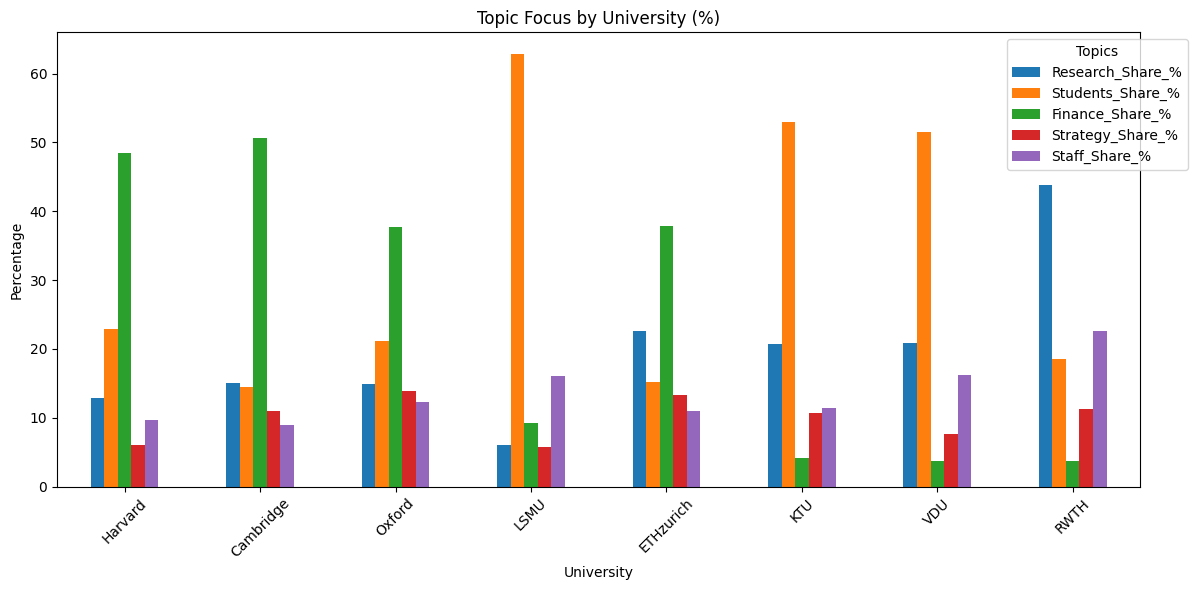

In [ ]:
topic_share_cols = [col + "_Share_%" for col in topic_columns]

plot_df = df_text.set_index("University")[topic_share_cols]

plot_df.plot(kind="bar", figsize=(12, 6))

plt.title("Topic Focus by University (%)")
plt.ylabel("Percentage")
plt.xlabel("University")
plt.xticks(rotation=45)
plt.legend(title="Topics", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

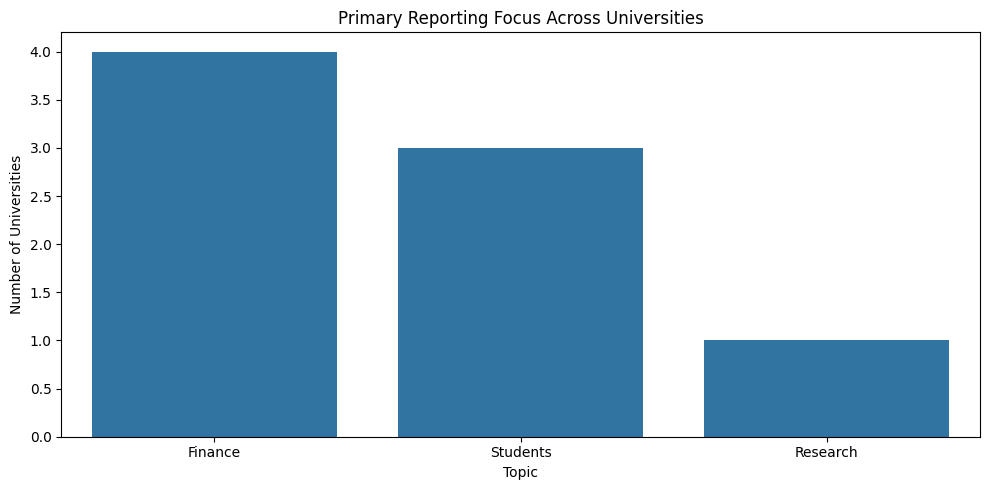

In [ ]:
focus_df = df_text.copy()

focus_df["Primary_Focus"] = focus_df[topic_share_cols].idxmax(axis=1)
focus_df["Primary_Focus"] = focus_df["Primary_Focus"].str.replace("_Share_%", "", regex=False)

plt.figure(figsize=(10, 5))
sns.countplot(data=focus_df,
              x="Primary_Focus",
              order=focus_df["Primary_Focus"].value_counts().index)

plt.title("Primary Reporting Focus Across Universities")
plt.xlabel("Topic")
plt.ylabel("Number of Universities")
plt.tight_layout()
plt.show()

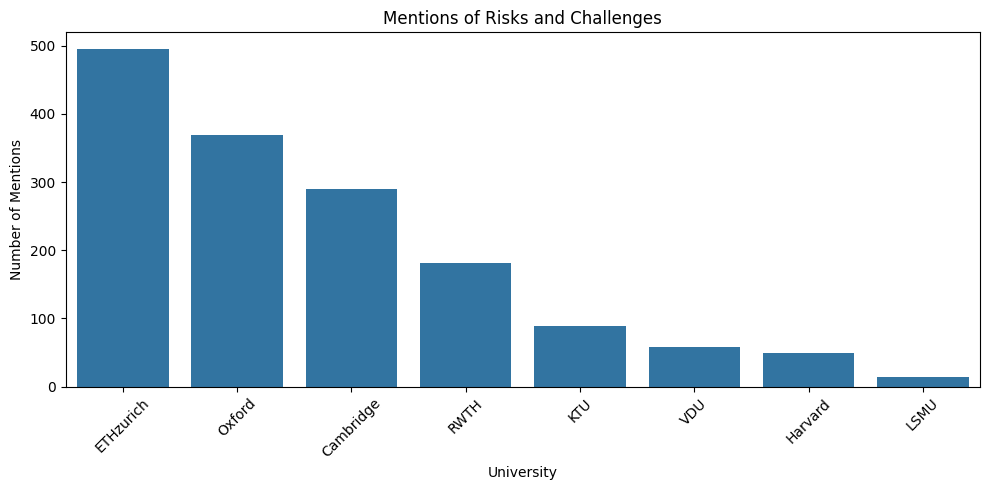

In [ ]:
risk_by_uni = (
    df_text[["University", "Risk_Mentions"]]
    .sort_values("Risk_Mentions", ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=risk_by_uni, x="University", y="Risk_Mentions")

plt.title("Mentions of Risks and Challenges")
plt.ylabel("Number of Mentions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

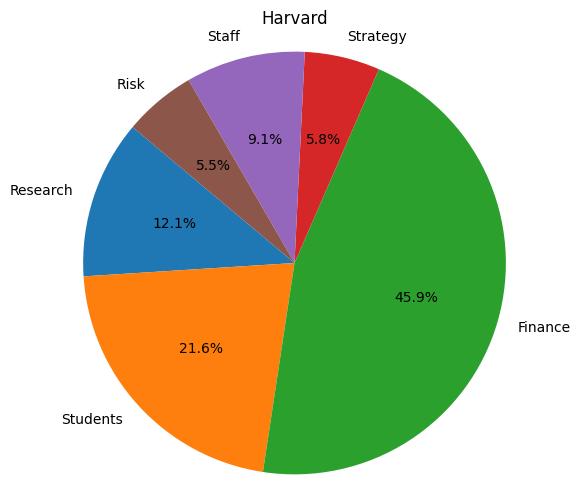

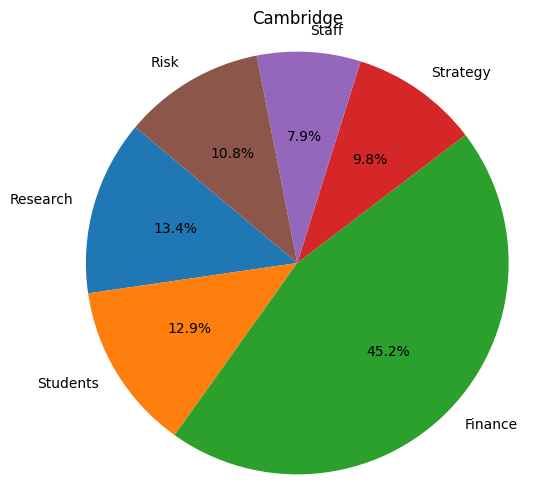

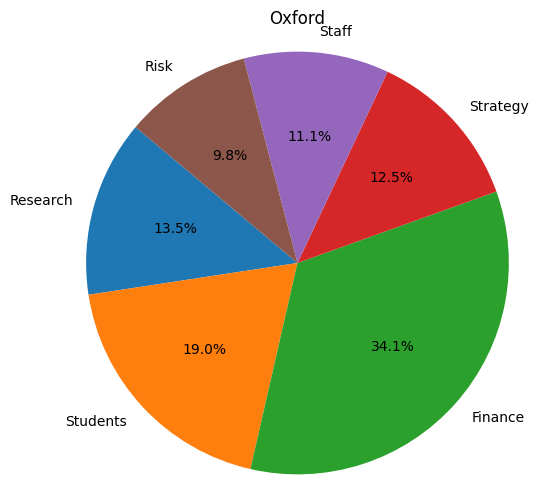

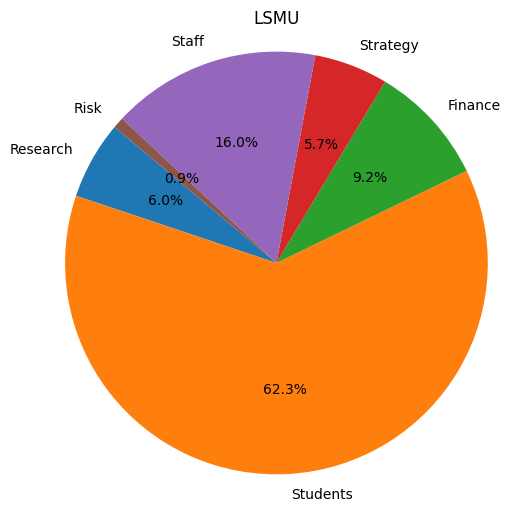

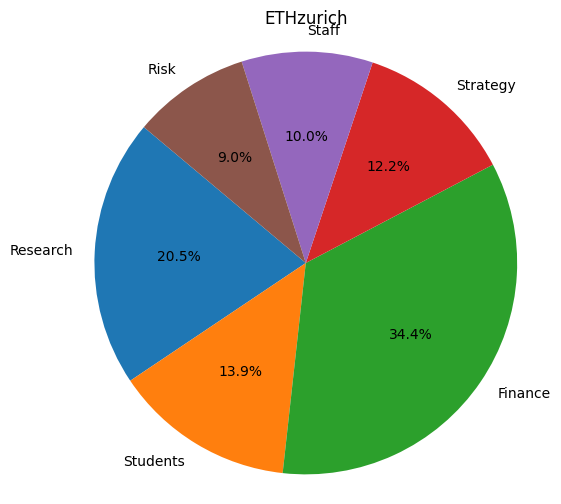

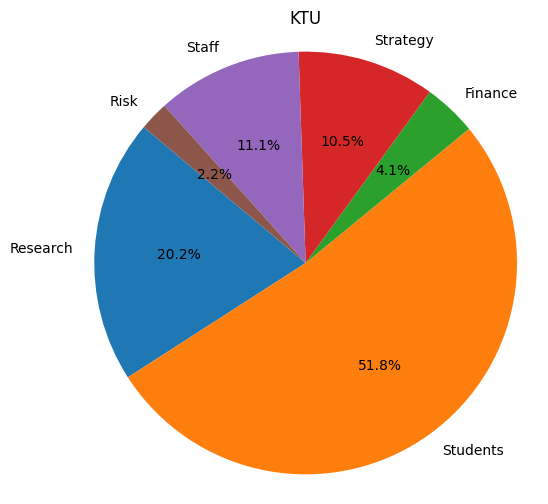

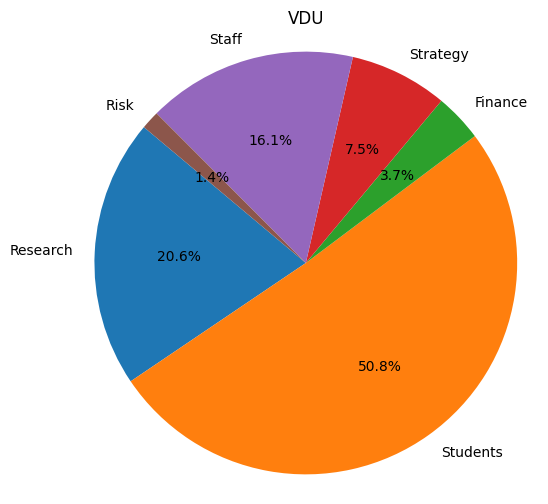

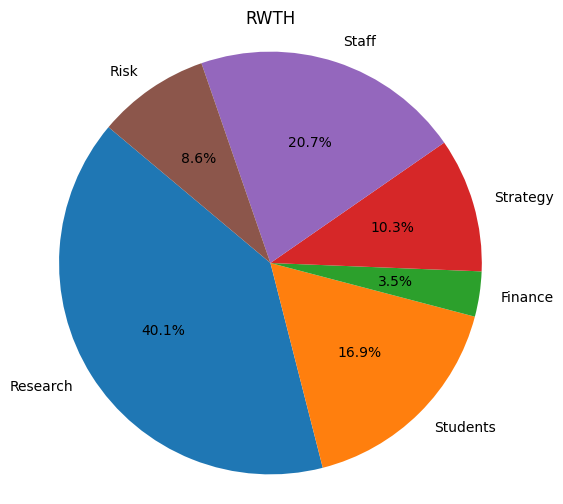

In [ ]:
for _, row in df_text.iterrows():

    topic_values = row[topic_share_cols].values
    risk_value = row["Risk_Share_%"]

    labels = topic_columns + ["Risk"]
    values = list(topic_values) + [risk_value]

    plt.figure(figsize=(6, 6))
    plt.pie(values,
            labels=labels,
            autopct='%1.1f%%',
            startangle=140)

    plt.title(f"{row['University']}")
    plt.axis('equal')
    plt.show()

In [ ]:
risk_words = ["risk", "challenge", "decline", "decrease", "deficit", "crisis", "uncertainty", "problem"]

df_text["Risk_Mentions"] = df_text["Clean_Text"].apply(lambda x: count_keywords(x, risk_words))

risk_by_uni = (
    df_text.groupby("University")["Risk_Mentions"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

risk_by_uni

,University,Risk_Mentions
0,ETHzurich,495
1,Oxford,369
2,Cambridge,290
3,RWTH,181
4,KTU,89
5,VDU,58
6,Harvard,49
7,LSMU,14
